### get historical data

In [1]:
### get data
import time
import pandas as pd
import numpy as np
import talib.abstract as ta
import ccxt

exchange = ccxt.binanceusdm({
	'apiKey': '',
	'secret': '',
})
# get klines from start to present
def get_history(symbol, interval, start= None, limit = 1000):
	if start:
		start = exchange.parse8601(start)

	data = exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, since=start, limit=limit) 
	lastBarActual = data[-1][0] # timestamp of last loaded bar
	# timestamp of current bar
	lastBarCurrent = exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, limit=1)[-1][0]
	# if lastBarActual != lastBarCurrent => pull the next 1000 bars
	while lastBarActual != lastBarCurrent:
		time.sleep(0.1)
		data += exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, since=lastBarActual, limit=limit)[1:]
		lastBarActual = data[-1][0]
		lastBarCurrent = exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, limit=1)[-1][0]

	df = pd.DataFrame(data)
	df.columns = ['date', 'open', 'high', 'low', 'close', 'volume']
	df.date= pd.to_datetime(df.date, unit='ms')
	df.set_index('date', inplace=True)
	
	return df
df = get_history("ETHUSDT", '1h', start='2022-01-01T00:00:00Z')
price_columns = ['open', 'high', 'low', 'close']
for col in price_columns:
    df[col] = df[col].mask((df[col] <= 0) | (df[col] > df[col].quantile(0.999)), np.nan)
    df[col] = df[col].ffill()


### research

In [9]:
import pandas as pd
import numpy as np
from pandas import DataFrame, Series
import talib.abstract as ta

def rsi_div(rsi: Series) -> DataFrame:
    rsi = rsi.copy()
    is_rsi_peak_at_tminus1 = (rsi.shift(1) > rsi.shift(2)) & (rsi.shift(1) > rsi)
    rsi_peak = rsi.shift(1).where(is_rsi_peak_at_tminus1).ffill()
    is_lower_peak = (rsi_peak < rsi_peak.shift(1)) & (rsi_peak > 70)  

    is_rsi_trough_at_tminus1 = (rsi.shift(1) < rsi.shift(2)) & (rsi.shift(1) < rsi)
    rsi_trough = rsi.shift(1).where(is_rsi_trough_at_tminus1).ffill()
    is_higher_trough = (rsi_trough > rsi_trough.shift(1)) & (rsi_trough < 30)

    conds = [is_lower_peak, is_higher_trough]
    choices= [-1, 1]
    rsi_div = np.select(conds, choices, default=0)

    # return pd.DataFrame({
    #     'bull_divergence': is_higher_trough, 
    #     'bear_divergence': is_lower_peak
    #     }, index=rsi.index)
    return rsi_div

In [5]:
df['rsi'] = ta.RSI(df, 14)

In [11]:
df['rsi_div'] = rsi_div(df['rsi'])

In [20]:
bull= (df.rsi_div==1).sum()
bear = (df.rsi_div==-1).sum()
print(f'bull:{bull}, bear:{bear}')

bull:238, bear:256


### better rsi_div

In [135]:
def gethl(arr, width=2, K=2):
  '''
  Finds consecutive higher lows in price pattern.
  Must not be exceeded within the number of periods indicated by the width 
  parameter for the value to be confirmed.
  K determines how many consecutive lows need to be higher.
  '''
  # Get lows
  low_idx = argrelextrema(arr, np.less, order=width)[0]
  # 解决未来函数问题
  confirmed_low_idx = low_idx + width
  valid_mask = confirmed_low_idx < len(arr)
  confirmed_low_idx = confirmed_low_idx[valid_mask] # real signal
  low_idx= low_idx[valid_mask] # original low_idx
  lows = arr[low_idx] # origin lows
  # Ensure consecutive lows are higher than previous lows
  extrema = []
  ex_deque = deque(maxlen=K)
  for i in range(len(low_idx)):
    if i == 0:
      ex_deque.append(confirmed_low_idx[i])
      continue
    if lows[i] < lows[i-1]:
      ex_deque.clear()
 
    ex_deque.append(confirmed_low_idx[i])
    if len(ex_deque) == K:
      extrema.append(ex_deque.copy())
   
  return extrema

def getlh(arr: np.array, width=2, k=2):
    # get lows
    high_idx = argrelextrema(arr, np.greater, order=width)[0] # np.array
    # clear 未来函数
    confirmed_high_idx = high_idx+ width
    valid_mask = confirmed_high_idx < len(arr)
    confirmed_high_idx = confirmed_high_idx[valid_mask]
    high_idx = high_idx[valid_mask]
    highs = arr[high_idx] # np.array
    # Ensure consecutive highs are lower than previous highs
    extrema = [] # [deque([high1_idx, high2_idx])]
    ex_deque = deque(maxlen=k) # [idx:int] -> [deque([low1_idx, low2_idx])]
    for i in range(len(high_idx)): # i, sequence[i]
        if i == 0:
           ex_deque.append(confirmed_high_idx[i]) 
           continue
        if highs[i] > highs[i-1]:
            ex_deque.clear()
        ex_deque.append(confirmed_high_idx[i])
        if len(ex_deque) == k:
            extrema.append(ex_deque.copy())
    return extrema

In [59]:
tdf = df.copy()

In [139]:
rsi_hl_idx = gethl(tdf['rsi'].values, 3, 2)
rsi_lh_idx = getlh(tdf['rsi'].values, 3, 2)

In [141]:
rsi_hl_idx[0]

deque([31, 37])

In [191]:
def mark_rsi_points(df, idx_list, col_name, high=None, low=None):
    '''
    extract every b from deque([a,b]),
    mark True in related idx @df.rsi_hh
    '''
    idx = [q[-1] for q in idx_list if len(q) > 0]
    if high:
        print(f'high={high}')
        df[col_name] = np.where(
            (df.index.isin(df.index[idx]) & (df['rsi'] > high)),
            -1, df['rsi_div']
        )
    else:
        print(f'low={low}')
        df[col_name] = np.where(
            (df.index.isin(df.index[idx]) & (df['rsi'] < low)),
            1, df['rsi_div']
        )
    return df

In [201]:
df.rsi

date
2022-01-01 00:00:00          NaN
2022-01-01 01:00:00          NaN
2022-01-01 02:00:00          NaN
2022-01-01 03:00:00          NaN
2022-01-01 04:00:00          NaN
                         ...    
2025-11-02 04:00:00    63.832963
2025-11-02 05:00:00    60.871612
2025-11-02 06:00:00    60.493822
2025-11-02 07:00:00    61.912140
2025-11-02 08:00:00    62.100002
Name: rsi, Length: 33633, dtype: float64

In [210]:
tdf['rsi_div'] = 0
tdf = mark_rsi_points(tdf, rsi_lh_idx, 'rsi_div', high=70)
tdf = mark_rsi_points(tdf, rsi_hl_idx, 'rsi_div', low=30)

high=70
low=30


In [211]:
(tdf.rsi_div == 1).sum()

29

In [212]:
import mplfinance as mpf
import matplotlib.pyplot as plt
import pandas as pd

# 假设 df.index 是 DatetimeIndex
# df.columns 包含: ['open','high','low','close','volume','rsi']

def plot_price_rsi_with_lines(df, rsi_hh_idx, rsi_ll_idx):
    # --- 1️⃣ 创建 figure 和 axes
    fig, (ax_price, ax_rsi) = plt.subplots(
        2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True
    )

    # --- 2️⃣ 绘制主图（价格）
    mpf.plot(df, type='candle', ax=ax_price, volume=False, show_nontrading=False)

    ax_price.set_title("Price + RSI Divergence Visualization", fontsize=14)

    # --- 3️⃣ 绘制副图（RSI）
    ax_rsi.plot(df.index, df["rsi"], label="RSI", color="blue", lw=1)
    ax_rsi.axhline(70, color='r', linestyle='--', lw=0.8)
    ax_rsi.axhline(30, color='g', linestyle='--', lw=0.8)
    ax_rsi.set_ylabel("RSI")

    # --- 4️⃣ 绘制 RSI 高点线段
    for i in range(len(rsi_hh_idx) - 1):
        x = [df.index[rsi_hh_idx[i]], df.index[rsi_hh_idx[i+1]]]
        y = [df["rsi"].iloc[rsi_hh_idx[i]], df["rsi"].iloc[rsi_hh_idx[i+1]]]
        ax_rsi.plot(x, y, color='red', lw=1.5)

    # --- 5️⃣ 绘制 RSI 低点线段
    for i in range(len(rsi_ll_idx) - 1):
        x = [df.index[rsi_ll_idx[i]], df.index[rsi_ll_idx[i+1]]]
        y = [df["rsi"].iloc[rsi_ll_idx[i]], df["rsi"].iloc[rsi_ll_idx[i+1]]]
        ax_rsi.plot(x, y, color='green', lw=1.5)

    # --- 6️⃣ 美化
    ax_rsi.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
plot_price_rsi_with_lines(tdf)

In [223]:
tdf['ret_5'] = tdf['close'].shift(-5)/tdf['close']- 1

In [217]:
tdf

,open,high,low,close,volume,rsi,rsi_div,rsi_hh,rsi_ll,ret_13,ret_8
date,,,,,,,,,,,
2022-01-01 00:00:00,3676.01,3730.00,3676.01,3721.67,45835.920,NaN,0,False,False,-0.003490,-0.003490
2022-01-01 01:00:00,3721.67,3747.78,3712.65,3723.71,39219.106,NaN,0,False,False,-0.007442,-0.007442
2022-01-01 02:00:00,3723.72,3735.42,3721.15,3727.03,18603.210,NaN,0,False,False,-0.000818,-0.000818
2022-01-01 03:00:00,3727.04,3734.62,3720.56,3722.07,12613.551,NaN,0,False,False,0.001179,0.001179
2022-01-01 04:00:00,3722.07,3726.63,3706.00,3707.30,27995.465,NaN,0,False,False,0.013894,0.013894
...,...,...,...,...,...,...,...,...,...,...,...
2025-11-02 04:00:00,3879.25,3915.98,3874.08,3907.21,116420.132,63.832963,0,False,False,NaN,NaN
2025-11-02 05:00:00,3907.22,3908.00,3893.00,3901.05,59945.420,60.871612,0,False,False,NaN,NaN
2025-11-02 06:00:00,3901.05,3906.74,3890.10,3900.28,40939.567,60.493822,0,False,False,NaN,NaN


In [ ]:
pdf = tdf.copy()

In [224]:
# 分组收益统计
bull_div_ret = tdf[tdf['rsi_div'] == 1]['ret_5']
bull_div_ret = bull_div_ret.dropna()
bear_div_ret = tdf[tdf['rsi_div'] == -1]['ret_5']
bear_div_ret = bear_div_ret.dropna()
no_signal_returns = tdf[tdf['rsi_div'] == 0]['ret_5']
no_signal_returns = no_signal_returns.dropna()

# 使用T检验检查收益差的显著性
from scipy.stats import ttest_ind
t_stat, t_pvalue = ttest_ind(bull_div_ret, no_signal_returns, equal_var=False)
print(f"收益差T检验P值: {t_pvalue:.4f}")

收益差T检验P值: 0.1026


In [227]:
print("信号均值:", bull_div_ret.mean())
print("无信号均值:", no_signal_returns.mean())
print("信号标准差:", bull_div_ret.std())
print("无信号标准差:", no_signal_returns.std())


信号均值: 0.006129873710458976
无信号均值: 0.0001342089641488782
信号标准差: 0.019128768448061544
无信号标准差: 0.016299252574295084


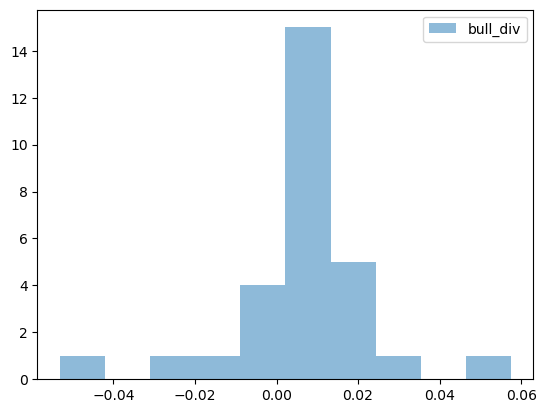

In [226]:
import matplotlib.pyplot as plt

plt.hist(bull_div_ret, bins=10, alpha=0.5, label='bull_div')
# plt.hist(no_signal_returns, bins=30, alpha=0.5, label='no_signal')
# plt.hist(bear_div_ret, bins= 30, alpha= 0.5, label='bear_div')
plt.legend()
plt.show()
